In [ ]:
# ===========================
# CELL 1: MASTER INSTALLATION
# ===========================
import os
import sys
import importlib

print("⏳ Step 1/8: Pinning Colab's required Pandas version FIRST...")
# Google Colab specifies pandas==2.2.2. Force it.
!pip install pandas==2.2.2 -q
print("✅ Colab's Pandas version pinned.")

print("\n⏳ Step 2/8: Verifying initial Numpy version...")
try:
    import numpy as np_check
    print(f"✅ Numpy version after pinning Pandas: {np_check.__version__}")
except ImportError:
    print("⚠️ Numpy not found yet, installing base essentials...")
    !pip install numpy cython wheel setuptools --upgrade -q

print("\n⏳ Step 3/8: Installing Build Tools...")
!pip install cython wheel setuptools --upgrade -q
print("✅ Build tools updated.")

# --- ** Install TA-Lib (C Library) ** ---
print("\n⏳ Step 4/8: Installing TA-Lib C library...")
!wget http://prdownloads.sourceforge.net/ta-lib/ta-lib-0.4.0-src.tar.gz -q
!tar -xzf ta-lib-0.4.0-src.tar.gz
%cd ta-lib/
!./configure --prefix=/usr -q
!make -s # Use -s for silent build
!make install -s
%cd ..
!rm -r ta-lib* # Clean up source files
print("✅ TA-Lib C library installed.")
# -----------------------------------------------------------

# --- Install Python TA-Lib Wrapper ---
print("\n⏳ Step 5/8: Installing TA-Lib Python wrapper...")
!pip install TA-Lib -q
print("✅ TA-Lib Python wrapper installed.")
# ------------------------------------

# --- Install other dependencies ---
print("\n⏳ Step 6/8: Installing other dependencies (Gymnasium, SB3, ta, etc.)...")
# *** ADDED 'ta' library here ***
!pip install gymnasium stable-baselines3[extra] gym==0.26.2 'shimmy>=1.0' yfinance exchange-calendars wrds websockets stockstats pyportfolioopt ta --upgrade -q
print("✅ Base & other FinRL dependencies installed (excluding Pyfolio, including ta).")
# ------------------------------------

# --- Manually Clone FinRL-Meta Repository ---
print("\n⏳ Step 7/8: Cloning FinRL-Meta repository from GitHub...")
!rm -rf FinRL-Meta/
!git clone https://github.com/AI4Finance-Foundation/FinRL-Meta.git -q

# --- Add FinRL-Meta to Python Path ---
print("\n⏳ Step 8/8: Adding FinRL-Meta to system path...")
finrl_meta_path = os.path.abspath('FinRL-Meta')
if finrl_meta_path not in sys.path:
    sys.path.append(finrl_meta_path)
    print(f"✅ Added '{finrl_meta_path}' to system path.")
else:
    print(f"FinRL-Meta path already in system path.")
# -------------------------------------------

print("\n\n✅✅✅ Installation Cell (Strategy 8 - NO Pyfolio, ADD ta) Complete. ✅✅✅")
print("⚠️ Pyfolio was SKIPPED. Standard FinRL-Meta backtesting scripts WILL FAIL.")
print("   You MUST implement your own performance evaluation after training.")

# --- Final Check: Import key libraries ---
print("\nVerifying key imports...")
try:
    import numpy
    import pandas
    import ta # Now checking the 'ta' library
    import gymnasium
    import stable_baselines3
    import meta # *** CORRECTED IMPORT HERE ***
    print("✅ Key libraries seem to import correctly.")
except Exception as e:
    print(f"🔥ERROR: A key library failed to import: {e}")

⏳ Step 1/8: Pinning Colab's required Pandas version FIRST...
✅ Colab's Pandas version pinned.

⏳ Step 2/8: Verifying initial Numpy version...
✅ Numpy version after pinning Pandas: 2.0.2

⏳ Step 3/8: Installing Build Tools...
✅ Build tools updated.

⏳ Step 4/8: Installing TA-Lib C library...
/content/ta-lib
appending configuration tag "CXX" to libtool
appending configuration tag "F77" to libtool
Making all in src
Making all in ta_abstract
mkdir .libs
 gcc -DHAVE_CONFIG_H -I. -I../../include -I../ta_common/ -Iframes/ -g -O2 -MT libta_abstract_la-ta_group_idx.lo -MD -MP -MF .deps/libta_abstract_la-ta_group_idx.Tpo -c ta_group_idx.c  -fPIC -DPIC -o .libs/libta_abstract_la-ta_group_idx.o
 gcc -DHAVE_CONFIG_H -I. -I../../include -I../ta_common/ -Iframes/ -g -O2 -MT libta_abstract_la-ta_group_idx.lo -MD -MP -MF .deps/libta_abstract_la-ta_group_idx.Tpo -c ta_group_idx.c -o libta_abstract_la-ta_group_idx.o >/dev/null 2>&1
 gcc -DHAVE_CONFIG_H -I. -I../../include -I../ta_common/ -Iframes/ -g -O2

In [ ]:
# ==================================
# CELL 2: MOUNT DRIVE & DEFINE PATHS 
# ==================================
from google.colab import drive
import os

print("\nMounting Google Drive...")
try:

    drive.mount('/content/drive')
    print("Google Drive mounted successfully.")

    BASE_PROJECT_PATH = r"/content/drive/MyDrive/Nifty50_RL_Project"
    PROCESSED_DIR = os.path.join(BASE_PROJECT_PATH, "finance_data", "processed")
    MODELS_DIR = os.path.join(BASE_PROJECT_PATH, "models")
    LOG_DIR = os.path.join(BASE_PROJECT_PATH, "logs")

    # Create folders in if they don't exist
    os.makedirs(PROCESSED_DIR, exist_ok=True)
    os.makedirs(MODELS_DIR, exist_ok=True)
    os.makedirs(LOG_DIR, exist_ok=True)

    print(f"\nAll paths are set. Base project path: {BASE_PROJECT_PATH}")
    print(f"Processed data dir: {PROCESSED_DIR}")
    print(f"Models will save to: {MODELS_DIR}")
    print(f"Logs will save to: {LOG_DIR}")

except Exception as e:
    print(f"Error mounting drive or creating directories: {e}")
    print("Please check your Drive permissions and ensure the BASE_PROJECT_PATH exists.")
    raise # Stop if drive mounting or path setup fails

print("\n✅ Setup cell finished.")


Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully.

All paths are set. Base project path: /content/drive/MyDrive/Nifty50_RL_Project
Processed data dir: /content/drive/MyDrive/Nifty50_RL_Project/finance_data/processed
Models will save to: /content/drive/MyDrive/Nifty50_RL_Project/models
Logs will save to: /content/drive/MyDrive/Nifty50_RL_Project/logs

✅ Setup cell finished.


In [ ]:
# ====================================
# CELL 3: DATA CLEANING AND PROCESSING
# ====================================
print("Starting: Loading Clean, Adding ALL Features (incl. ATR, Benchmark, VIX)...")

import pandas as pd
import numpy as np
import os
from stockstats import StockDataFrame as Sdf
import traceback
from ta.volatility import AverageTrueRange
import yfinance as yf

# Define file path for the CLEAN data
clean_filepath = os.path.join(PROCESSED_DIR, "_NIFTY50_CLEAN_LONG_FORMAT.csv")

# =======================================
# STEP 1: LOAD CLEAN DATA
# =======================================
print(f"\nLoading clean data from: {clean_filepath}")
try:
    df_clean = pd.read_csv(clean_filepath)
    df_clean['date'] = pd.to_datetime(df_clean['date'])
    df_clean = df_clean.rename(columns={'date': 'time'})
    df_clean = df_clean.sort_values(['time', 'tic']).reset_index(drop=True)
    print(f"Clean data loaded. Shape: {df_clean.shape}")
except Exception as e:
    print(f"An error occurred loading clean data: {e}")
    raise

# =======================================
# STEP 2: ADD STANDARD TECHNICAL INDICATORS
# =======================================
print("\nAdding standard technical indicators...")
try:
    stock_df_orig = df_clean.copy()
    unique_tickers_list = stock_df_orig['tic'].unique()
    all_indicators_list = []
    total_tickers = len(unique_tickers_list)
    required_cols_for_stockstats = ['time', 'open', 'high', 'low', 'close', 'volume']

    for i, ticker in enumerate(unique_tickers_list):
        temp_df_ticker = stock_df_orig[stock_df_orig.tic == ticker][required_cols_for_stockstats].copy()
        if len(temp_df_ticker) < 200:
            print(f"Warning: Insufficient data for {ticker} (< 200 rows). Skipping.")
            continue

        temp_df_ticker = temp_df_ticker.reset_index()
        temp_df_ticker_sdf_input = temp_df_ticker.rename(columns={'time':'date'}).copy()
        temp_sdf = Sdf.retype(temp_df_ticker_sdf_input)

        # Calculate stockstats indicators
        temp_sdf['macd']
        temp_sdf['rsi_14']
        temp_sdf['boll']
        temp_sdf['close_20_sma']
        temp_sdf['close_50_sma']
        temp_sdf['close_100_sma']
        temp_sdf['close_200_sma']
        temp_sdf['volume_12_ema']
        temp_sdf['volume_26_ema']
        temp_sdf['vo'] = temp_sdf['volume_12_ema'] - temp_sdf['volume_26_ema']

        # Calculate ATR using 'ta'
        atr_calc = AverageTrueRange(
            high=temp_df_ticker["high"], low=temp_df_ticker["low"],
            close=temp_df_ticker["close"], window=14
        )
        temp_df_ticker["atr"] = atr_calc.average_true_range()

        indicator_cols = {
            'macd': 'macd', 'rsi_14': 'rsi', 'boll_ub': 'boll_ub', 'boll_lb': 'boll_lb',
            'close_20_sma': 'sma_20', 'close_50_sma': 'sma_50', 'close_100_sma': 'sma_100',
            'close_200_sma': 'sma_200', 'vo': 'vo'
        }
        cols_to_keep = ['index'] + list(indicator_cols.keys())
        temp_indicators = temp_sdf[[col for col in cols_to_keep if col in temp_sdf.columns]].copy()
        temp_indicators = temp_indicators.rename(columns=indicator_cols)

        temp_df_merged = pd.merge(temp_df_ticker, temp_indicators, on='index', how='left')
        temp_df_merged['tic'] = ticker
        temp_df_merged = temp_df_merged.drop(columns=['index'])
        all_indicators_list.append(temp_df_merged)

    if not all_indicators_list:
        raise ValueError("No tickers had sufficient data for indicator calculation.")
    df_with_indicators = pd.concat(all_indicators_list, ignore_index=True)
    print("All standard indicators added and merged.")

except Exception as e:
    print(f"Error adding standard indicators: {e}")
    traceback.print_exc()
    raise

# ========================
# STEP 2.1: FILTER BY DATE
# =========================
START_DATE_FILTER = "2010-01-01"
print(f"\nFiltering all data to start after {START_DATE_FILTER}...")
df_with_indicators = df_with_indicators[df_with_indicators['time'] >= START_DATE_FILTER].copy()
if df_with_indicators.empty:
    raise ValueError(f"No data remaining after filtering for start date {START_DATE_FILTER}.")
print(f"Data trimmed. New shape: {df_with_indicators.shape}, New start date: {df_with_indicators['time'].min()}")

# =================================================
# STEP 2.2: ADD BENCHMARK (NIFTY 50) & VIX FEATURES
# =================================================
print("\nDownloading and adding Nifty 50 (^NSEI) and VIX (^INDIAVIX) features...")
try:
    min_date = df_with_indicators['time'].min()
    max_date = df_with_indicators['time'].max()

    index_df = yf.download(['^NSEI', '^INDIAVIX'], start=min_date, end=max_date, auto_adjust=False)
    if index_df.empty:
        raise ValueError("Failed to download index data.")

    # --- Process Nifty 50 ---
    nifty_ohlc = index_df.loc[:, (slice(None), '^NSEI')]
    nifty_ohlc.columns = nifty_ohlc.columns.droplevel(1)
    nifty_ohlc = nifty_ohlc.rename(columns=str.lower)
    nifty_sdf = Sdf.retype(nifty_ohlc)

    # Calculate Nifty 50 indicators (using ONLY stockstats)
    nifty_sdf['rsi_14']
    nifty_sdf['close_50_sma']
    nifty_sdf['atr_14'] 

    nifty_features = nifty_sdf[['rsi_14', 'close_50_sma', 'atr_14']].rename(columns={
        'rsi_14': 'NIFTY_RSI',
        'close_50_sma': 'NIFTY_SMA_50',
        'atr_14': 'NIFTY_ATR' 
    })

    # --- Process VIX ---
    vix_ohlc = index_df.loc[:, (slice(None), '^INDIAVIX')]
    vix_ohlc.columns = vix_ohlc.columns.droplevel(1)
    vix_ohlc = vix_ohlc.rename(columns=str.lower)

    vix_sdf = Sdf.retype(vix_ohlc)
    vix_sdf['close_20_sma']
    vix_features = vix_sdf[['close_20_sma']].rename(columns={'close_20_sma': 'VIX_SMA_20'})

    # --- Combine and Merge ---
    benchmark_features = pd.concat([nifty_features, vix_features], axis=1)
    benchmark_features = benchmark_features.reset_index().rename(columns={'Date': 'time'})

    df_with_indicators = pd.merge(df_with_indicators, benchmark_features, on='time', how='left')
    print("✅ Benchmark and VIX indicators merged.")

except Exception as e:
    print(f"🔥Error adding benchmark/VIX features: {e}. Proceeding without them...")
    traceback.print_exc()

# ==============================
# STEP 2.3: Clean remaining NaNs
# ==============================
indicator_output_cols = [
    'macd', 'rsi', 'boll_ub', 'boll_lb', 'sma_20', 'sma_50', 'sma_100', 'sma_200', 'vo', 'atr',
    'NIFTY_RSI', 'NIFTY_SMA_50', 'NIFTY_ATR', 'VIX_SMA_20' #New features
]
numeric_cols = df_with_indicators.select_dtypes(include=np.number).columns.tolist()
initial_rows = len(df_with_indicators)
df_with_indicators[numeric_cols] = df_with_indicators[numeric_cols].replace([np.inf, -np.inf], np.nan)
print(f"\nReplaced inf values in numeric columns.")

columns_to_check_for_nan = ['time', 'open', 'high', 'low', 'close', 'volume', 'tic'] + indicator_output_cols
df_with_indicators.dropna(subset=[col for col in columns_to_check_for_nan if col in df_with_indicators.columns], inplace=True)
rows_dropped = initial_rows - len(df_with_indicators)
if rows_dropped > 0:
    print(f"Dropped {rows_dropped} rows due to remaining NaN values (incl. benchmark NaNs).")
if df_with_indicators.empty:
    raise ValueError("DataFrame is empty after dropping remaining NaNs.")

# =================================
# STEP 3: CREATE A BALANCED DATASET
# =================================
print("\nVerifying data consistency and building a balanced dataset...")
ticker_day_counts = df_with_indicators.groupby('tic')['time'].nunique()
max_days = ticker_day_counts.max()
print(f"Max days found for any single ticker: {max_days}")
min_days_required = max_days * 0.99
complete_tickers_list = ticker_day_counts[ticker_day_counts >= min_days_required].index.tolist()
print(f"Found {len(complete_tickers_list)} tickers with >99% data (>= {min_days_required} days).")
if len(complete_tickers_list) < 2:
    raise ValueError(f"Only found {len(complete_tickers_list)} tickers with >99% data. Cannot create a portfolio.")
df_filtered_tickers = df_with_indicators[df_with_indicators['tic'].isin(complete_tickers_list)]
df_pivot = df_filtered_tickers.pivot(index='time', columns='tic', values='close')
df_pivot_balanced = df_pivot.dropna(axis=0)
common_dates = df_pivot_balanced.index
print(f"Found {len(common_dates)} trading days common to all {len(complete_tickers_list)} tickers.")
stock_tickers = sorted(complete_tickers_list)
df_final_processed = df_with_indicators[
    (df_with_indicators['tic'].isin(stock_tickers)) &
    (df_with_indicators['time'].isin(common_dates))
].copy()
print(f"✅✅✅ Final number of tickers for environment: {len(stock_tickers)} ✅✅✅")
print(f"   Tickers: {stock_tickers}")
print(f"   Total days for all tickers: {len(common_dates)}")

# ============================
# STEP 4: CALCULATE TURBULENCE
# ============================
print("\nCalculating Turbulence Index manually...")
def calculate_turbulence(df, window=252):
    df_copy = df.sort_values(['time', 'tic']).copy()
    unique_tics = sorted(df_copy['tic'].unique())
    num_tickers = len(unique_tics)
    if num_tickers < 2:
        print("Warning: Not enough tickers to calculate turbulence. Returning 0.")
        df_copy['turbulence'] = 0.0
        return df_copy
    try:
        df_price_pivot = df_copy.pivot(index="time", columns="tic", values="close")
    except ValueError as e:
        print(f"Error pivoting data for turbulence: {e}.")
        raise
    df_returns_pivot = df_price_pivot.pct_change(fill_method=None)
    effective_window = min(window, len(df_returns_pivot) - 1)
    if effective_window < 2:
        print(f"Warning: Not enough data for turbulence calculation. Returning 0.")
        df_copy['turbulence'] = 0.0
        return df_copy
    print(f"Using turbulence window: {effective_window}")
    rolling_mean = df_returns_pivot.rolling(window=effective_window, min_periods=effective_window).mean()
    turbulence_index = []
    dates_with_turbulence = df_returns_pivot.index[effective_window:]
    print(f"Calculating turbulence for {len(dates_with_turbulence)} dates...")
    for date in dates_with_turbulence:
        current_returns = df_returns_pivot.loc[date].values
        current_mean = rolling_mean.loc[date].values
        window_start_idx = df_returns_pivot.index.get_loc(date) - effective_window + 1
        window_data = df_returns_pivot.iloc[window_start_idx : window_start_idx + effective_window]
        current_cov = window_data.cov().values
        diff = current_returns - current_mean
        if np.isnan(diff).any():
            diff = np.nan_to_num(diff, nan=0.0)
        try:
            current_cov = np.nan_to_num(current_cov, nan=0.0, posinf=1e5, neginf=-1e5)
            current_cov += np.identity(current_cov.shape[0]) * 1e-8
            inv_cov = np.linalg.pinv(current_cov)
            turbulence = diff.dot(inv_cov).dot(diff.T)
            turbulence = turbulence / max(1, num_tickers)
            if turbulence < 0: turbulence = 0.0
        except (np.linalg.LinAlgError, IndexError, ValueError) as e:
            turbulence = np.nan
        turbulence_index.append(turbulence)
    turbulence_df = pd.DataFrame({'time': dates_with_turbulence, 'turbulence': turbulence_index})
    df_copy = df_copy.merge(turbulence_df, on='time', how='left')
    df_copy['turbulence'] = df_copy['turbulence'].ffill().bfill().fillna(0)
    turb_q99 = df_copy['turbulence'].quantile(0.99)
    if turb_q99 > 0:
        df_copy['turbulence'] = np.clip(df_copy['turbulence'], 0, turb_q99)
        print(f"Turbulence clipped at 99th percentile: {turb_q99:.4f}")
    else:
        print("Turbulence is zero or constant, no clipping applied.")
    return df_copy
try:
    df_final_processed = calculate_turbulence(df_final_processed)
    print("Turbulence index calculated and merged successfully.")
except Exception as e:
    print(f"Error calculating turbulence manually: {e}")
    if 'turbulence' not in df_final_processed.columns:
         df_final_processed['turbulence'] = 0.0
    print("Added turbulence=0 due to error.")

# ============================
# STEP 5: CALCULATE COVARIANCE
# ============================
print("\nCalculating and adding covariance list (cov_list)...")
lookback_period_cov = 252
num_tickers_cov = len(stock_tickers)
df_returns_pivot_cov = df_final_processed.pivot(index="time", columns="tic", values="close")[stock_tickers].pct_change(fill_method=None)
effective_lookback_cov = min(lookback_period_cov, len(df_returns_pivot_cov) - 1)
if effective_lookback_cov < 2:
     raise ValueError(f"Lookback period ({effective_lookback_cov}) too small for covariance calc.")
print(f"Using covariance lookback period: {effective_lookback_cov}")
print("Calculating rolling covariance...")
rolling_cov_obj = df_returns_pivot_cov.rolling(window=effective_lookback_cov, min_periods=effective_lookback_cov).cov(pairwise=True)
cov_data = []
unique_dates_cov = df_final_processed['time'].unique()
print(f"Processing covariance matrices for {len(unique_dates_cov)} dates...")
for date in unique_dates_cov:
    if date in rolling_cov_obj.index.get_level_values(0):
        try:
            cov_matrix_df = rolling_cov_obj.loc[date].reindex(index=stock_tickers, columns=stock_tickers)
            cov_matrix_np = np.nan_to_num(cov_matrix_df.values, nan=0.0, posinf=0.0, neginf=0.0)
            cov_matrix_list = cov_matrix_np.tolist()
        except Exception as e_cov:
             cov_matrix_list = np.nan
    else:
        cov_matrix_list = np.nan
    cov_data.append((date, cov_matrix_list))
cov_df = pd.DataFrame(cov_data, columns=['time', 'cov_list'])
df_final_processed = df_final_processed.merge(cov_df, on='time', how='left')
print("Handling NaNs in 'cov_list' (from initial lookback period)...")
df_final_processed['cov_list'] = df_final_processed['cov_list'].ffill()
initial_rows_cov = len(df_final_processed)
df_final_processed.dropna(subset=['cov_list'], inplace=True)
dropped_rows_cov = initial_rows_cov - len(df_final_processed)
if dropped_rows_cov > 0:
    print(f"Dropped {dropped_rows_cov} rows due to initial covariance NaN (after ffill).")
if df_final_processed.empty:
     raise ValueError("DataFrame became empty after dropping initial NaN covariance rows.")
print("✅ 'cov_list' column added successfully.")

# =================================
# STEP 6: FINAL SPLIT & INDEX RESET
# =================================
print("\nSplitting final, consistent data...")
TRAIN_START_DATE_STR = df_final_processed['time'].min().strftime('%Y-%m-%d')
TRAIN_END_DATE_STR = '2017-12-31'
VAL_START_DATE_STR = '2018-01-01'
VAL_END_DATE_STR = '2019-12-31'
TEST_START_DATE_STR = '2020-01-01'
TEST_END_DATE_STR = df_final_processed['time'].max().strftime('%Y-%m-%d')
print(f"Train Period: {TRAIN_START_DATE_STR} to {TRAIN_END_DATE_STR}")
print(f"Val Period:   {VAL_START_DATE_STR} to {VAL_END_DATE_STR}")
print(f"Test Period:  {TEST_START_DATE_STR} to {TEST_END_DATE_STR}")
TRAIN_START_DATE = pd.to_datetime(TRAIN_START_DATE_STR)
TRAIN_END_DATE = pd.to_datetime(TRAIN_END_DATE_STR)
VAL_START_DATE = pd.to_datetime(VAL_START_DATE_STR)
VAL_END_DATE = pd.to_datetime(VAL_END_DATE_STR)
TEST_START_DATE = pd.to_datetime(TEST_START_DATE_STR)
TEST_END_DATE = pd.to_datetime(TEST_END_DATE_STR)
df_train_final = df_final_processed[(df_final_processed['time'] >= TRAIN_START_DATE) & (df_final_processed['time'] <= TRAIN_END_DATE)].copy()
df_val_final = df_final_processed[(df_final_processed['time'] >= VAL_START_DATE) & (df_final_processed['time'] <= VAL_END_DATE)].copy()
df_test_final = df_final_processed[(df_final_processed['time'] >= TEST_START_DATE) & (df_final_processed['time'] <= TEST_END_DATE)].copy()
if df_train_final.empty: raise ValueError("Training DataFrame (df_train_final) is empty after split.")
if df_val_final.empty: print("\n⚠️ Warning: Validation DataFrame (df_val_final) is empty after split.")
if df_test_final.empty: print("\n⚠️ Warning: Test DataFrame (df_test_final) is empty after split.")
print("\nResetting index for all data splits...")
df_train_final = df_train_final.reset_index(drop=True)
df_val_final = df_val_final.reset_index(drop=True)
df_test_final = df_test_final.reset_index(drop=True)
print("✅ Index reset complete.")
print(f"\n✅ Data loaded, v3 features added, filtered, and split successfully.")
print(f"   Train shape: {df_train_final.shape}")
print(f"   Val shape:   {df_val_final.shape}")
print(f"   Test shape:  {df_test_final.shape}")

Starting: Loading Clean, Adding ALL Features (incl. ATR, Benchmark, VIX)...

Loading clean data from: /content/drive/MyDrive/Nifty50_RL_Project/finance_data/processed/_NIFTY50_CLEAN_LONG_FORMAT.csv
Clean data loaded. Shape: (222859, 7)

Adding standard technical indicators...


[*********************100%***********************]  2 of 2 completed

All standard indicators added and merged.

Filtering all data to start after 2010-01-01...
Data trimmed. New shape: (189371, 17), New start date: 2010-01-04 00:00:00



✅ Benchmark and VIX indicators merged.

Replaced inf values in numeric columns.
Dropped 295 rows due to remaining NaN values (incl. benchmark NaNs).

Verifying data consistency and building a balanced dataset...
Max days found for any single ticker: 3895
Found 46 tickers with >99% data (>= 3856.05 days).
Found 3895 trading days common to all 46 tickers.
✅✅✅ Final number of tickers for environment: 46 ✅✅✅
   Tickers: ['ADANIENT.NS', 'ADANIPORTS.NS', 'APOLLOHOSP.NS', 'ASIANPAINT.NS', 'AXISBANK.NS', 'BAJAJ-AUTO.NS', 'BAJAJFINSV.NS', 'BAJFINANCE.NS', 'BHARTIARTL.NS', 'BPCL.NS', 'BRITANNIA.NS', 'CIPLA.NS', 'DIVISLAB.NS', 'DRREDDY.NS', 'EICHERMOT.NS', 'GRASIM.NS', 'HCLTECH.NS', 'HDFCBANK.NS', 'HEROMOTOCO.NS', 'HINDALCO.NS', 'HINDUNILVR.NS', 'ICICIBANK.NS', 'INDUSINDBK.NS', 'INFY.NS', 'ITC.NS', 'JSWSTEEL.NS', 'KOTAKBANK.NS', 'LT.NS', 'M&M.NS', 'MARUTI.NS', 'NESTLEIND.NS', 'NTPC.NS', 'ONGC.NS', 'POWERGRID.NS', 'RELIANCE.NS', 'SBIN.NS', 'SHREECEM.NS', 'SUNPHARMA.NS', 'TATACONSUM.NS', 'TATAMOTOR

In [ ]:
# ==============================================
# CELL 4: DEFINE KWARGS (Tuned + Benchmark + VIX)
# ==============================================
print("Defining environment keyword arguments (v3 - Tuned + Benchmark + VIX)...")

import numpy as np
import pandas as pd

if 'df_train_final' not in locals(): raise NameError("df_train_final not defined.")
if 'stock_tickers' not in locals(): raise NameError("stock_tickers not defined.")
print(f"   Found {len(stock_tickers)} tickers to train on.")

#   --- Define Features list including NIFTY and VIX indicators ---
FEATURES = ["close", "high", "low"] + [
    'macd', 'rsi', 'boll_ub', 'boll_lb', 'sma_20',
    'sma_50', 'sma_100', 'sma_200', 'vo', 'atr'
] + [
    # --- BENCHMARK & VIX FEATURES ---
    'NIFTY_RSI', 'NIFTY_SMA_50', 'NIFTY_ATR', 'VIX_SMA_20'
]
FEATURES = [f for f in FEATURES if f in df_train_final.columns]
print(f"Using {len(FEATURES)} features for state space: {FEATURES}")

missing_features = [f for f in FEATURES if f not in df_train_final.columns]
if missing_features:
    raise ValueError(f"Required features missing from df_train_final: {missing_features}.")

# --- Define Base Parameters Matching __init__ ---
base_params = {
    "initial_amount": 1000000,
    "reward_scaling": 1e-4,
    "comission_fee_pct": 0.001,
    "features": FEATURES, # Pass the new, larger feature list
    "valuation_feature": "close",
    "time_column": "time",
    "tic_column": "tic",
    "time_window": 10, # Keep the 10-day window for memory
    "new_gym_api": False,

    # --- penalty for the wrapper to use ---
    "risk_aversion_penalty": 0.5 # <--- This will be read by the wrapper
}

# --- Create env_kwargs for Training ---
env_kwargs = base_params.copy()
env_kwargs["df"] = df_train_final
print(f"\nTraining env_kwargs created.")

# --- Create env_kwargs for Validation ---
if not df_val_final.empty:
    env_kwargs_val = base_params.copy()
    env_kwargs_val["df"] = df_val_final
    val_features = [f for f in FEATURES if f in df_val_final.columns]
    env_kwargs_val["features"] = val_features
    print("\nValidation env_kwargs_val created.")
else:
    env_kwargs_val = None
    print("\nValidation data is empty. env_kwargs_val set to None.")

print("\n✅ v3 Environment keyword arguments defined.")

Defining environment keyword arguments (v3 - Tuned + Benchmark + VIX)...
   Found 46 tickers to train on.
Using 17 features for state space: ['close', 'high', 'low', 'macd', 'rsi', 'boll_ub', 'boll_lb', 'sma_20', 'sma_50', 'sma_100', 'sma_200', 'vo', 'atr', 'NIFTY_RSI', 'NIFTY_SMA_50', 'NIFTY_ATR', 'VIX_SMA_20']

Training env_kwargs created.

Validation env_kwargs_val created.

✅ v3 Environment keyword arguments defined.


In [27]:

!pip install quantstats --upgrade --no-cache-dir -q
print("✅ quantstats installed.")

✅ quantstats installed.


In [ ]:
# ======================================
# CELL 4.5: Gymnasium Native Wrapper
# ======================================
print("Defining Gymnasium-native wrapper (v6 - Drawdown Penalty)...")

import gymnasium as gym
from gymnasium import spaces
import numpy as np
import time
import traceback
import gym as old_gym
try:
    from meta.env_portfolio_optimization.env_portfolio_optimization import PortfolioOptimizationEnv as FinRLStockPortfolioEnv
    print("✅ Successfully imported PortfolioOptimizationEnv as FinRLStockPortfolioEnv.")
except ImportError as e:
    print(f"🔥Error importing FinRLStockPortfolioEnv: {e}")
    raise

class StockPortfolioEnvGymnasiumWrapper(gym.Env):
    """
    FINAL v6 Gymnasium wrapper.
    - Flattens 3D observation space for MlpPolicy.
    - Adds a custom Drawdown Penalty to the reward.
    """
    metadata = {"render_modes": [], "render_fps": 30}

    def __init__(self, **kwargs):
        super().__init__()
        try:
            # ---  Get risk penalty from kwargs ---
            self.risk_aversion_penalty = kwargs.get("risk_aversion_penalty", 0.0)

            # Create a copy of kwargs to pass to internal env, removing custom one
            internal_kwargs = kwargs.copy()
            if "risk_aversion_penalty" in internal_kwargs:
                del internal_kwargs["risk_aversion_penalty"]

            self.finrl_env = FinRLStockPortfolioEnv(**internal_kwargs) # Pass cleaned kwargs
            print(f"Wrapper Init: Internal FinRL env ({type(self.finrl_env).__name__}) initialized.")

            if self.risk_aversion_penalty > 0:
                print(f"   ✅ Wrapper applying Drawdown Penalty: {self.risk_aversion_penalty}")
            # ------------------------------------------------

            if not hasattr(self.finrl_env, 'observation_space') or not hasattr(self.finrl_env, 'action_space'):
                 raise AttributeError("Internal FinRL environment did not define 'observation_space' or 'action_space'.")

            obs_space_internal = self.finrl_env.observation_space
            act_space_internal = self.finrl_env.action_space
            if not isinstance(obs_space_internal, old_gym.spaces.Box) or not isinstance(act_space_internal, old_gym.spaces.Box):
                 raise TypeError("Internal FinRL environment's spaces are not of type gym.spaces.Box.")

            obs_size = np.prod(obs_space_internal.shape)
            obs_shape_tuple = (int(obs_size),)
            self.internal_state_space_size = obs_size
            print(f"Wrapper Init: Read internal obs_space shape {obs_space_internal.shape}, size {obs_size}")
            print(f"Wrapper Init: FLATTENING obs space to {obs_shape_tuple}")
            act_shape = act_space_internal.shape
            print(f"Wrapper Init: Read internal act_space shape {act_shape}")
            self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=obs_shape_tuple, dtype=np.float32)
            self.action_space = spaces.Box(low=act_space_internal.low, high=act_space_internal.high, shape=act_shape, dtype=np.float32)

        except Exception as e:
            print(f"Error initializing wrapper or reading internal env spaces: {e}")
            traceback.print_exc()
            raise
        print(f"Wrapper: Initialized internal FinRL Env.")
        print(f"Wrapper: Obs Space (Gymnasium): {self.observation_space}")
        print(f"Wrapper: Act Space (Gymnasium): {self.action_space}")
        try:
            self.initial_amount = self.finrl_env._initial_amount
            self.reward_scaling = getattr(self.finrl_env, '_reward_scaling', 1.0)
            self._stock_dim = getattr(self.finrl_env, '_stock_dim', self.action_space.shape[0])
            self.high_water_mark = self.initial_amount # <-- Init high-water mark
            print(f"Wrapper: Copied initial_amount ({self.initial_amount}), reward_scaling ({self.reward_scaling}), _stock_dim ({self._stock_dim})")
        except AttributeError as e_attr:
             print(f"🔥Error copying attributes after init: {e_attr}.")
             raise

    def _convert_obs(self, obs):
        float_obs = None
        try: float_obs = np.array(obs, dtype=np.float64)
        except ValueError as e:
            print(f"Warning: ValueError during initial obs conversion: {e}. Trying item-by-item.")
            temp_list = []
            if hasattr(obs, '__iter__'):
                for item in obs:
                    if isinstance(item, dict): continue
                    try: temp_list.extend(np.ravel(item))
                    except (TypeError, ValueError):
                        try: temp_list.append(float(item))
                        except (ValueError, TypeError): temp_list.append(0.0)
            float_obs = np.array(temp_list, dtype=np.float64)
        if float_obs is None: float_obs = np.zeros(self.observation_space.shape, dtype=np.float64)
        float_obs = np.nan_to_num(float_obs, nan=0.0, posinf=1e6, neginf=-1e6)
        float_obs = np.clip(float_obs, -np.inf, np.inf)
        try:
            reshaped_obs = float_obs.reshape(self.observation_space.shape)
            final_obs = reshaped_obs.astype(self.observation_space.dtype)
        except ValueError as e_shape:
            print(f"Warning (Obs Convert): Reshape failed ({float_obs.shape} -> {self.observation_space.shape}). Padding/Truncating.")
            expected_size = np.prod(self.observation_space.shape)
            float_obs = float_obs.flatten()
            if float_obs.size < expected_size: float_obs = np.concatenate((float_obs, np.zeros(expected_size - float_obs.size, dtype=np.float64)))
            elif float_obs.size > expected_size: float_obs = float_obs[:expected_size]
            try: final_obs = float_obs.reshape(self.observation_space.shape).astype(self.observation_space.dtype)
            except Exception as e_final: raise ValueError(f"FATAL: Obs conversion failed even after padding/truncating: {e_final}")
        return final_obs

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
             if hasattr(self.finrl_env, '_np_random') and hasattr(self.finrl_env._np_random, 'seed'): self.finrl_env._np_random.seed(seed)
             elif hasattr(self.finrl_env, 'seed'): self.finrl_env.seed(seed)
        obs_original = self.finrl_env.reset()
        observation = self._convert_obs(obs_original)
        self.high_water_mark = self.initial_amount
        asset_memory = getattr(self.finrl_env, '_asset_memory', [])
        current_portfolio_value = asset_memory[-1] if isinstance(asset_memory, (list, np.ndarray)) and len(asset_memory) > 0 else self.initial_amount
        info = {
            "portfolio_value": current_portfolio_value, "weights": self._init_weights_fallback(),
            "date": getattr(self.finrl_env, '_time_index', 0)
        }
        return observation, info

    def step(self, action):
        current_step_index = getattr(self.finrl_env, '_time_index', 'unknown')
        if not isinstance(action, np.ndarray): action = np.array(action)
        if action.shape != self.action_space.shape:
             if action.size == np.prod(self.action_space.shape): action = action.reshape(self.action_space.shape)
             else: raise ValueError(f"Action Shape Mismatch! Expected {self.action_space.shape}, got {action.shape}")
        clipped_action = np.clip(action, self.action_space.low, self.action_space.high)
        if self.action_space.shape[0] > 0:
            exp_action = np.exp(clipped_action - np.max(clipped_action))
            sum_exp = np.sum(exp_action)
            if sum_exp < 1e-10 or np.isnan(sum_exp): action_weights = np.ones(self._stock_dim) / self._stock_dim
            else: action_weights = exp_action / sum_exp
            action_weights = np.nan_to_num(action_weights, nan=(1.0/self._stock_dim))
            action_weights = np.maximum(action_weights, 0.0)
            action_weights /= np.sum(action_weights)
            action_to_pass = action_weights
        else: action_to_pass = np.array([])
        try:
            step_result = self.finrl_env.step(action_to_pass)
            if len(step_result) == 4:
                obs_original, reward_original, done, info_original = step_result
                terminated, truncated = bool(done), False
            else: raise ValueError(f"Internal env.step() returned {len(step_result)} values, expected 4.")
            if not isinstance(info_original, dict): info_original = {}
        except Exception as e:
            print(f"CRITICAL ERROR during internal FinRL step call at index {current_step_index}: {e}")
            traceback.print_exc()
            last_obs = np.zeros(self.observation_space.shape, dtype=self.observation_space.dtype)
            info = { "error": str(e), "internal_exception": True }
            return last_obs, -1.0 * self.initial_amount * self.reward_scaling, True, False, info

        observation = self._convert_obs(obs_original)
        info = info_original
        asset_memory = getattr(self.finrl_env, '_asset_memory', {})
        final_value_list = asset_memory.get('final', [])
        info["portfolio_value"] = portfolio_value = final_value_list[-1] if final_value_list else np.nan
        weights_hist = getattr(self.finrl_env, '_actions_memory', [])
        info["weights"] = weights_hist[-1] if weights_hist else self._init_weights_fallback()
        info["date"] = getattr(self.finrl_env, '_time_index', 0)
        if 'done' in info: del info['done']

        # --- *** NEW: DRAWDOWN PENALTY LOGIC *** ---
        drawdown_penalty = 0.0
        if not np.isnan(portfolio_value):
            if portfolio_value > self.high_water_mark:
                self.high_water_mark = portfolio_value
            drawdown = (portfolio_value / self.high_water_mark) - 1.0 # This will be <= 0
            if drawdown < 0:
                drawdown_penalty = self.risk_aversion_penalty * abs(drawdown)

        final_reward = reward_original - drawdown_penalty
        reward = float(final_reward) * self.reward_scaling
        # --- *** END NEW LOGIC *** ---

        return observation, reward, terminated, truncated, info

    def _init_weights_fallback(self):
        stock_dim = self._stock_dim
        if stock_dim > 0: weights = np.array([1.0] + [0.0] * stock_dim)
        else: weights = np.array([1.0])
        return weights
    def render(self):
        if hasattr(self.finrl_env, 'render'): self.finrl_env.render()
        else: pass
    def close(self):
        if hasattr(self.finrl_env, 'close'): self.finrl_env.close()

print("✅ Gymnasium-native wrapper defined (v6 - Drawdown Penalty).")

Defining Gymnasium-native wrapper (v6 - Drawdown Penalty)...
✅ Successfully imported PortfolioOptimizationEnv as FinRLStockPortfolioEnv.
✅ Gymnasium-native wrapper defined (v6 - Drawdown Penalty).


In [ ]:
# =======================================
# CELL 5: FINETUNE v2 MODEL (Create "v2+")
# =======================================
print("Starting v2 Finetuning... Loading v2 model and training with new parameters.")

from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback, CheckpointCallback, CallbackList
from stable_baselines3.common.env_util import make_vec_env
import time
import numpy as np
import os
import sys
import traceback
import torch.nn as nn
import logging
import torch

# --- Suppress Matplotlib Font Warnings ---
font_manager_logger = logging.getLogger('matplotlib.font_manager')
font_manager_logger.setLevel(logging.ERROR)
print("   Matplotlib font warnings suppressed.")
# ----------------------------------------

# --- *** 1. V2 MODEL TO FINETUNE *** ---
# !!! PASTE THE FULL PATH to your v2 model (the 10-day window, 1.131 Sharpe one)
V2_MODEL_TO_FINETUNE_PATH = "/content/drive/MyDrive/Nifty50_RL_Project/models/ppo_model_20251029-055855_flat_10day_auto.zip" # <-- UPDATE THIS PATH
# -----------------------------------------------

# --- *** 2. NEW FINETUNING PARAMETERS *** ---
FINETUNE_LEARNING_RATE = 0.00005 # <--- Very slow learning rate for stability
FINETUNE_TOTAL_TIMESTEPS = 300_000 # <--- A shorter run (300k) is often enough for finetuning
FINETUNE_N_STEPS = 2048
FINETUNE_BATCH_SIZE = 64
# -----------------------------------------

# --- Define *NEW* Model Save Paths (v2_finetuned) ---
timestr = time.strftime("%Y%m%d-%H%M%S")
PPO_MODEL_PATH = os.path.join(MODELS_DIR, f"ppo_model_{timestr}_v2_finetuned")
BEST_MODEL_SAVE_PATH = os.path.join(MODELS_DIR, f"best_model_{timestr}_v2_finetuned")
CHECKPOINT_SAVE_PATH = os.path.join(MODELS_DIR, f"checkpoints_{timestr}_v2_finetuned/")

# =======================================
# ⚙️ CREATE THE GYMNASIUM-NATIVE ENVIRONMENTS
# =======================================
print("\nCreating vectorized Gymnasium-native environments...")
if 'env_kwargs' not in locals(): raise NameError("env_kwargs not defined. Re-run Cell 4 first.")
if 'env_kwargs_val' not in locals(): raise NameError("env_kwargs_val not defined. Re-run Cell 4 first.")

def create_env_lambda(kwargs):
    local_kwargs = kwargs.copy()
    return lambda: StockPortfolioEnvGymnasiumWrapper(**local_kwargs)

n_envs = 1
env_train_vec = make_vec_env(create_env_lambda(env_kwargs), n_envs=n_envs, seed=42)
env_val_vec = make_vec_env(create_env_lambda(env_kwargs_val), n_envs=n_envs) if env_kwargs_val else None
print("   ✅ Environments re-created.")

# =======================================
# ⚙️ LOAD THE V2 PPO AGENT
# =======================================
print(f"\nLoading v2 model from: {V2_MODEL_TO_FINETUNE_PATH}")
if not os.path.exists(V2_MODEL_TO_FINETUNE_PATH):
    raise FileNotFoundError(f"Checkpoint file not found: {V2_MODEL_TO_FINETUNE_PATH}")

if torch.cuda.is_available(): device = "cuda"; else: device = "cpu"
print(f"   Auto-detecting device: {device.upper()}")

try:
    model_ppo = PPO.load(
        V2_MODEL_TO_FINETUNE_PATH,
        env=env_train_vec, # Re-link the environment
        tensorboard_log=LOG_DIR,
        device=device
    )

    # --- *** SET NEW (FINETUNING) PARAMETERS *** ---
    model_ppo.learning_rate = FINETUNE_LEARNING_RATE
    model_ppo.n_steps = FINETUNE_N_STEPS
    model_ppo.batch_size = FINETUNE_BATCH_SIZE

    print("   ✅ PPO (MlpPolicy) v2 agent loaded successfully.")
    print(f"   >>> Set new learning rate to: {model_ppo.learning_rate}")

except Exception as e:
    print(f"   🔥🔥🔥 Error loading PPO agent: {e}")
    raise

# =======================================
# ⚙️ SETUP CALLBACKS (for new save locations)
# =======================================
print("\nSetting up evaluation and checkpoint callbacks...")
EVAL_FREQ = 20000
N_EVAL_EPISODES = 3
eval_callback = None
if env_val_vec is not None:
    eval_callback = EvalCallback(
        eval_env=env_val_vec, best_model_save_path=BEST_MODEL_SAVE_PATH, # <-- Saves to new "best_model" path
        log_path=LOG_DIR, eval_freq=max(EVAL_FREQ // n_envs, 1),
        n_eval_episodes=N_EVAL_EPISODES, deterministic=True, render=False
    )
    print("   ✅ EvalCallback created.")
CHECKPOINT_FREQ = 20000 # Save every 20k steps
checkpoint_callback = CheckpointCallback(
    save_freq=max(CHECKPOINT_FREQ // n_envs, 1),
    save_path=CHECKPOINT_SAVE_PATH, # <-- Saves to new "checkpoints" folder
    name_prefix="ppo_model_v2_finetuned"
)
print(f"   ✅ CheckpointCallback created (saves every {CHECKPOINT_FREQ} steps).")
callback_list = [checkpoint_callback]
if eval_callback is not None: callback_list.append(eval_callback)
combined_callback = CallbackList(callback_list)

# =======================================
# 🚀 START FINETUNING
# =======================================
print(f"\n🚀 Starting finetuning for {FINETUNE_TOTAL_TIMESTEPS} timesteps...")
start_time = time.time()
if eval_callback:
    print(f"   Best model will be saved to: {BEST_MODEL_SAVE_PATH}")
print(f"   Periodic checkpoints will be saved in: {CHECKPOINT_SAVE_PATH}")
print(f"   Logs will be saved to: {LOG_DIR}")

try:
    model_ppo.learn(
        total_timesteps=FINETUNE_TOTAL_TIMESTEPS,
        reset_num_timesteps=True, # <-- We are starting a NEW run from 0
        log_interval=10,
        callback=combined_callback,
        progress_bar=True
    )
    end_time = time.time()
    print(f"\n✅ Finetuning finished successfully. Time taken: {(end_time - start_time):.2f} seconds.")

    print(f"\n💾 Saving final finetuned model to: {PPO_MODEL_PATH}")
    model_ppo.save(PPO_MODEL_PATH)
    print("   ✅ Final model saved successfully.")

except Exception as e:
    print(f"\n🔥🔥🔥 FATAL ERROR occurred during training: {e}")
    traceback.print_exc(file=sys.stdout)
    INTERRUPTED_MODEL_PATH = os.path.join(MODELS_DIR, f"ppo_model_INTERRUPTED_v2_finetune.zip")
    try:
        print(f"   Attempting to save model after error to: {INTERRUPTED_MODEL_PATH}")
        model_ppo.save(INTERRUPTED_MODEL_PATH)
        print("   ✅ Interrupted model saved.")
    except Exception as save_e:
        print(f"      Could not save interrupted model: {save_e}")

print("\n✅ Step 5 (Finetuning) finished (or interrupted).")

Starting v2 Finetuning... Loading v2 model and training with new parameters.
   Matplotlib font warnings suppressed.

Creating vectorized Gymnasium-native environments...
Normalizing ['close', 'high', 'low', 'macd', 'rsi', 'boll_ub', 'boll_lb', 'sma_20', 'sma_50', 'sma_100', 'sma_200', 'vo', 'atr', 'NIFTY_RSI', 'NIFTY_SMA_50', 'NIFTY_ATR', 'VIX_SMA_20'] by previous time...
Wrapper Init: Internal FinRL env (PortfolioOptimizationEnv) initialized.
   ✅ Wrapper applying Drawdown Penalty: 0.5
Wrapper Init: Read internal obs_space shape (17, 46, 10), size 7820
Wrapper Init: FLATTENING obs space to (7820,)
Wrapper Init: Read internal act_space shape (47,)
Wrapper: Initialized internal FinRL Env.
Wrapper: Obs Space (Gymnasium): Box(-inf, inf, (7820,), float32)
Wrapper: Act Space (Gymnasium): Box(0.0, 1.0, (47,), float32)
Wrapper: Copied initial_amount (1000000), reward_scaling (0.0001), _stock_dim (46)
Normalizing ['close', 'high', 'low', 'macd', 'rsi', 'boll_ub', 'boll_lb', 'sma_20', 'sma_50'

ValueError: Observation spaces do not match: Box(-inf, inf, (5980,), float32) != Box(-inf, inf, (7820,), float32)

Starting Manual Backtesting for v3 Model...
Loading best v3 model from: /content/drive/MyDrive/Nifty50_RL_Project/models/best_model_20251030-115552_v3_tuned_benchmark.zip
✅ Model loaded successfully onto CPU.
Creating test environment (with v3 features)...
Normalizing ['close', 'high', 'low', 'macd', 'rsi', 'boll_ub', 'boll_lb', 'sma_20', 'sma_50', 'sma_100', 'sma_200', 'vo', 'atr', 'NIFTY_RSI', 'NIFTY_SMA_50', 'NIFTY_ATR', 'VIX_SMA_20'] by previous time...
Wrapper Init: Internal FinRL env (PortfolioOptimizationEnv) initialized.
   ✅ Wrapper applying Drawdown Penalty: 0.5
Wrapper Init: Read internal obs_space shape (17, 46, 10), size 7820
Wrapper Init: FLATTENING obs space to (7820,)
Wrapper Init: Read internal act_space shape (47,)
Wrapper: Initialized internal FinRL Env.
Wrapper: Obs Space (Gymnasium): Box(-inf, inf, (7820,), float32)
Wrapper: Act Space (Gymnasium): Box(0.0, 1.0, (47,), float32)
Wrapper: Copied initial_amount (1000000), reward_scaling (0.0001), _stock_dim (46)
✅ v3 T

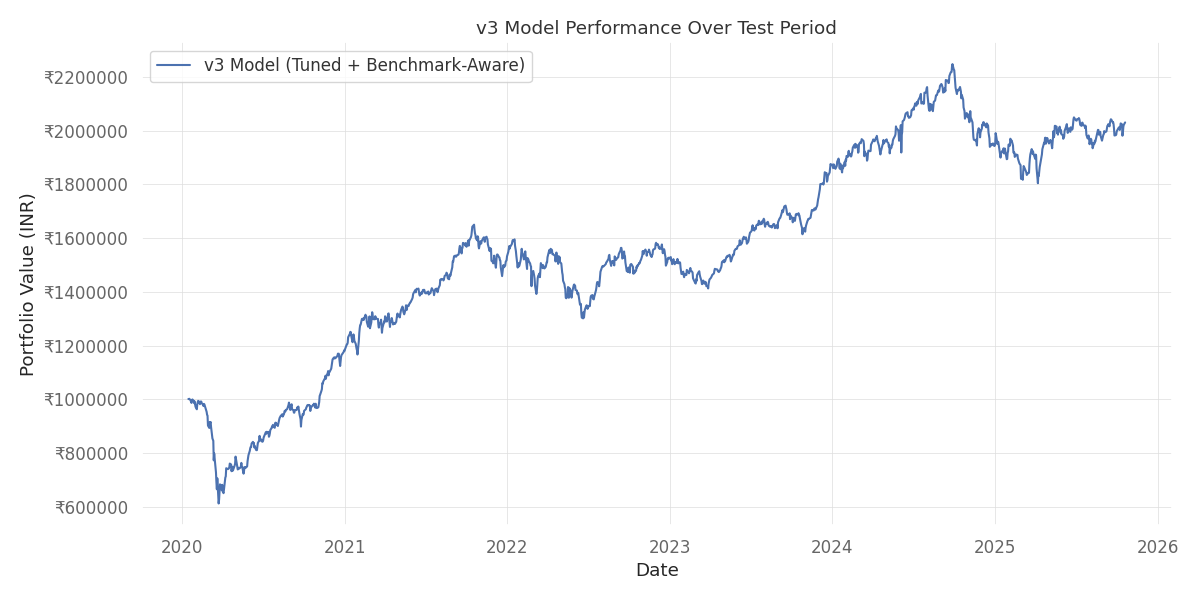


✅ Manual Backtesting Finished.


In [ ]:
# ==================================================
# CELL 6: BACKTEST v3 MODEL (Tuned + Benchmark-Aware)
# ==================================================
print("Starting Manual Backtesting for v3 Model...")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from stable_baselines3 import PPO
import os
import traceback
import torch
from IPython.display import Image, display

# --- Ensure Test Data and Wrapper Exist ---
if 'df_test_final' not in locals() or df_test_final.empty:
    raise NameError("df_test_final is not defined or is empty. Run Cell 3 again.")
if 'StockPortfolioEnvGymnasiumWrapper' not in locals():
     raise NameError("StockPortfolioEnvGymnasiumWrapper class not defined. Run Cell 4.5 again.")
if 'env_kwargs' not in locals():
     raise NameError("env_kwargs structure not defined. Run the final corrected Cell 4 again.")
if 'TEST_START_DATE_STR' not in locals():
     raise NameError("TEST_START_DATE_STR not defined. Run Cell 4 again.")

# --- Get Model Paths from Cell 5 ---
if 'BEST_MODEL_SAVE_PATH' not in locals() or not BEST_MODEL_SAVE_PATH:
     raise NameError("BEST_MODEL_SAVE_PATH not defined. Training (Cell 5) must complete first.")
if 'PPO_MODEL_PATH' not in locals() or not PPO_MODEL_PATH:
     raise NameError("PPO_MODEL_PATH not defined. Training (Cell 5) must complete first.")
# ------------------------------

# --- Load the Trained Agent ---
# We load the BEST model from the validation callback
MODEL_TO_LOAD = BEST_MODEL_SAVE_PATH + ".zip"
print(f"Loading best v3 model from: {MODEL_TO_LOAD}")

if not os.path.exists(MODEL_TO_LOAD):
    print(f"Warning: Best model not found. Attempting to load FINAL v3 model from: {PPO_MODEL_PATH}.zip")
    MODEL_TO_LOAD = PPO_MODEL_PATH + ".zip"
    if not os.path.exists(MODEL_TO_LOAD):
        raise FileNotFoundError(f"Trained v3 model not found at {PPO_MODEL_PATH}.zip or {BEST_MODEL_SAVE_PATH}.zip.")

try:
    if torch.cuda.is_available(): device = "cuda"
    else: device = "cpu"

    model = PPO.load(MODEL_TO_LOAD, device=device)
    print(f"✅ Model loaded successfully onto {device.upper()}.")
except Exception as e:
    print(f"🔥🔥🔥 Error loading model: {e}")
    raise

# --- Create Test Environment ---
print("Creating test environment (with v3 features)...")
try:
    test_env_kwargs = env_kwargs.copy()
    test_env_kwargs["df"] = df_test_final
    if "random_start" in test_env_kwargs:
         del test_env_kwargs["random_start"]

    env_test = StockPortfolioEnvGymnasiumWrapper(**test_env_kwargs)
    print("✅ v3 Test environment created.")
    unique_test_dates = env_test.finrl_env._sorted_times
    print(f"   Found {len(unique_test_dates)} unique dates in test set.")

except Exception as e:
    print(f"🔥🔥🔥 Error creating test environment: {e}")
    traceback.print_exc()
    raise

# --- Manual Backtesting Loop ---
print("\nRunning backtesting loop...")
obs, info = env_test.reset()

account_values = [env_test.initial_amount]
all_weights = [info.get("weights", [])]
rewards_memory = []
initial_date_index = getattr(env_test.finrl_env, '_time_index', 0)
try:
    initial_date = df_test_final.iloc[initial_date_index * env_test._stock_dim]['time']
except IndexError:
     initial_date = pd.Timestamp(TEST_START_DATE_STR)
dates = [initial_date]

terminated = False
truncated = False
step_count = 0
max_steps = len(unique_test_dates)

while not (terminated or truncated):
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env_test.step(action)

    asset_memory_dict = getattr(env_test.finrl_env, '_asset_memory', {})
    final_value_list = asset_memory_dict.get('final', [])
    portfolio_value = final_value_list[-1] if final_value_list else account_values[-1]

    current_date_index = info.get("date", step_count)
    current_weights = info.get("weights", [])

    rewards_memory.append(reward)
    all_weights.append(current_weights)

    if not np.isnan(portfolio_value) and current_date_index < len(unique_test_dates):
         account_values.append(portfolio_value)
         actual_date = pd.Timestamp(unique_test_dates[current_date_index])
         if not dates or actual_date != dates[-1]:
              dates.append(actual_date)

    step_count += 1
    if step_count % 100 == 0:
        print(f"  Day: {step_count}/{max_steps}, Portfolio Value: {portfolio_value:.2f}")

    if step_count >= max_steps:
         print("Reached end of test data.")
         break

print("✅ Backtesting loop finished.")

# --- Process Results ---
print("\nProcessing results...")
min_len = min(len(account_values), len(dates))
account_values = account_values[:min_len]
dates = dates[:min_len]

if not dates:
     print("🔥ERROR: No dates were recorded. Cannot process results.")
else:
    # Store results in a new variable: v3_results_df
    v3_results_df = pd.DataFrame({'date': dates, 'account_value': account_values})
    v3_results_df['date'] = pd.to_datetime(v3_results_df['date'])
    v3_results_df = v3_results_df.drop_duplicates(subset='date', keep='last')
    v3_results_df = v3_results_df.set_index('date')
    v3_results_df = v3_results_df.sort_index()

    v3_results_df['daily_return'] = v3_results_df['account_value'].pct_change(1)
    if not v3_results_df.empty and pd.isna(v3_results_df['daily_return'].iloc[0]):
        v3_results_df = v3_results_df.iloc[1:]

    print("\nCalculating Performance Metrics for v3 Model...")
    if v3_results_df.empty or v3_results_df['account_value'].isnull().all():
         print("  No valid data to calculate metrics.")
    else:
        try:
            initial_value = v3_results_df['account_value'].dropna().iloc[0]
            final_value = v3_results_df['account_value'].dropna().iloc[-1]
            total_return = (final_value / initial_value) - 1

            daily_returns = v3_results_df['daily_return']
            num_trading_days = len(daily_returns)
            num_years = num_trading_days / 252.0
            annualized_return = ((1 + total_return) ** (1 / max(num_years, 1/252.0))) - 1 if num_years > 0 else 0
            daily_std_dev = daily_returns.std()
            if daily_std_dev == 0 or np.isnan(daily_std_dev): sharpe_ratio = 0.0
            else: sharpe_ratio = (daily_returns.mean() / daily_std_dev) * np.sqrt(252)

            cumulative_returns = (1 + daily_returns).cumprod()
            peak = cumulative_returns.expanding(min_periods=1).max()
            drawdown = (cumulative_returns / peak) - 1
            max_drawdown = drawdown.min()

            winning_days = (daily_returns > 0).sum()
            losing_days = (daily_returns <= 0).sum()
            win_rate = (winning_days / num_trading_days) if num_trading_days > 0 else 0.0
            avg_win_return = daily_returns[daily_returns > 0].mean()
            avg_loss_return = daily_returns[daily_returns <= 0].mean()

            hold_days = 0
            change_tolerance = 0.02
            if len(all_weights) > 1:
                last_weights = np.array(all_weights[0])
                for weights in all_weights[1:]:
                    current_weights = np.array(weights)
                    if len(current_weights) == len(last_weights):
                        weight_change = np.abs(current_weights - last_weights)
                        if np.all(weight_change < change_tolerance):
                            hold_days += 1
                    last_weights = current_weights
            total_decision_days = len(all_weights) - 1
            hold_day_pct = (hold_days / total_decision_days) if total_decision_days > 0 else 0.0

            print(f"--- Strategy Returns ---")
            print(f"  Test Period Start Date: {v3_results_df.index.min().strftime('%Y-%m-%d')}")
            print(f"  Test Period End Date:   {v3_results_df.index.max().strftime('%Y-%m-%d')}")
            print(f"  Initial Portfolio Value: ₹{initial_value:,.2f}")
            print(f"  Final Portfolio Value:   ₹{final_value:,.2f}")
            print(f"  Total Return:            {total_return:.2%}")
            print(f"  Annualized Return:       {annualized_return:.2%}")

            print(f"\n--- Risk & Ratios ---")
            print(f"  Annualized Volatility:   {daily_std_dev * np.sqrt(252):.2%}")
            print(f"  Sharpe Ratio (Rf=0%):    {sharpe_ratio:.3f}")
            print(f"  Maximum Drawdown:        {max_drawdown:.2%}")

            print(f"\n--- Trade Behavior ---")
            print(f"  Total Trading Days:      {num_trading_days}")
            print(f"  Winning Days:            {winning_days}")
            print(f"  Losing Days:             {losing_days}")
            print(f"  Win Rate:                {win_rate:.2%}")
            print(f"  Avg. Win Day Return:     {avg_win_return:.4%}")
            print(f"  Avg. Loss Day Return:    {avg_loss_return:.4%}")
            print(f"  Hold Day Percentage:     {hold_day_pct:.2%} (Agent held position)")

        except Exception as e_metrics:
            print(f"🔥Error calculating metrics: {e_metrics}")
            traceback.print_exc()

    # --- Plot Results ---
    print("\nPlotting portfolio value...")
    if v3_results_df.empty or v3_results_df['account_value'].isnull().all():
         print("  No results to plot.")
    else:
        try:
            plt.figure(figsize=(12, 6))
            plt.plot(v3_results_df.index, v3_results_df['account_value'], label='v3 Model (Tuned + Benchmark-Aware)')
            plt.title('v3 Model Performance Over Test Period')
            plt.xlabel('Date')
            plt.ylabel('Portfolio Value (INR)')
            plt.gca().yaxis.set_major_formatter(mtick.FormatStrFormatter('₹%.0f'))
            plt.legend()
            plt.grid(True)
            plt.tight_layout()

            plot_path = "/content/v3_backtest_plot.png"
            plt.savefig(plot_path)
            plt.close()
            print(f"✅ Plot saved to {plot_path}")
            display(Image(filename=plot_path))

        except Exception as e_plot:
             print(f"🔥Error plotting results: {e_plot}")

print("\n✅ Manual Backtesting Finished.")

EXTRA

Starting Final Comparison: v1 vs. v2 vs. v3 vs. Nifty 50 vs. Equal-Weight...
Using device: CPU

Running backtest for model (window=1)...
Normalizing ['close', 'high', 'low', 'macd', 'rsi', 'boll_ub', 'boll_lb', 'sma_20', 'sma_50', 'sma_100', 'sma_200', 'vo', 'atr'] by previous time...
Wrapper Init: Internal FinRL env (PortfolioOptimizationEnv) initialized.
Wrapper Init: Read internal obs_space shape (13, 46, 1), size 598
Wrapper Init: FLATTENING obs space to (598,)
Wrapper Init: Read internal act_space shape (47,)
Wrapper: Initialized internal FinRL Env.
Wrapper: Obs Space (Gymnasium): Box(-inf, inf, (598,), float32)
Wrapper: Act Space (Gymnasium): Box(0.0, 1.0, (47,), float32)
Wrapper: Copied initial_amount (1000000), reward_scaling (0.0001), _stock_dim (46)
   ✅ Env created. Tickers: 46, Features: 13, Window: 1, Risk Penalty: 0.0
Initial portfolio value:1000000
Final portfolio value: 1725406.625
Final accumulative portfolio value: 1.7254066467285156
Maximum DrawDown: -0.3829581688781

[*********************100%***********************]  1 of 1 completed


   ✅ Nifty 50 data processed.

Calculating Equal-Weight Benchmark...
   ✅ Equal-Weight data processed.

--- 4. Plotting Final Comparison ---
✅ Plot saved to /content/final_comparison_plot.png


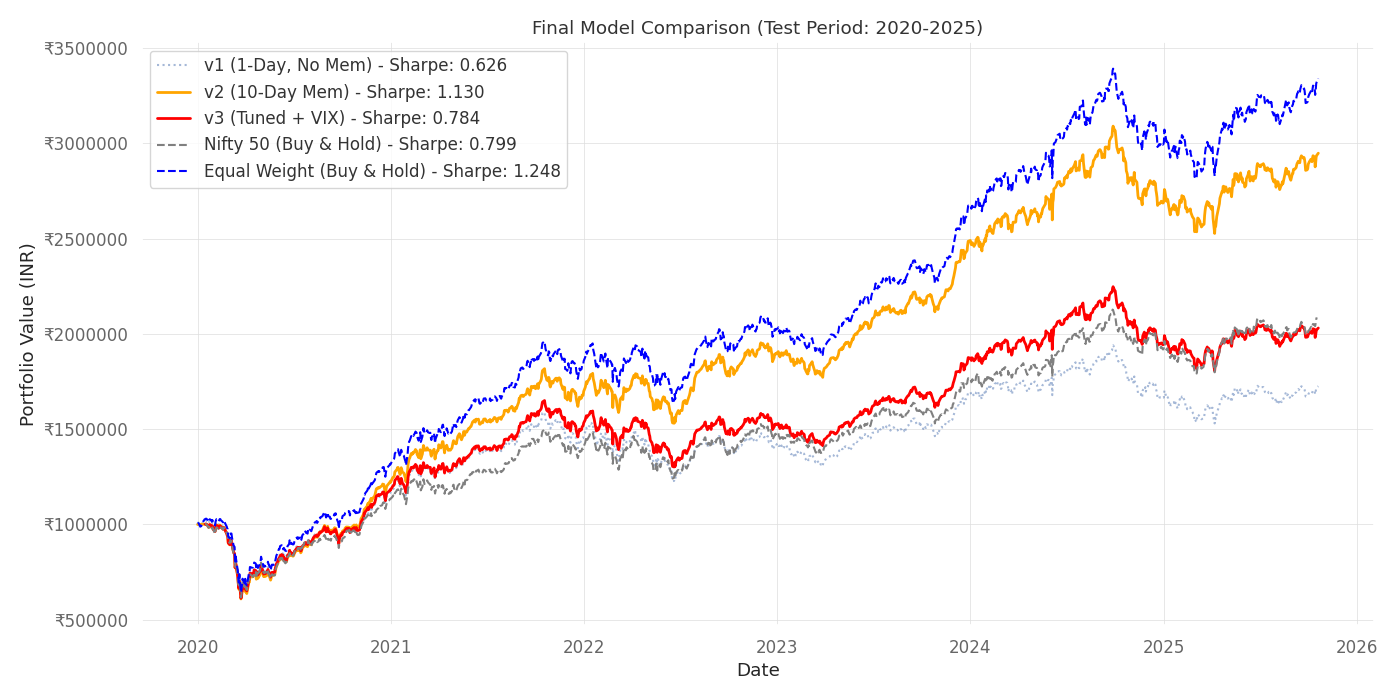


--- Regime Analysis (Annualized Sharpe Ratio) ---

--- Sharpe Ratio by Year ---
|   date |   v1 (1-Day Window) |   v2 (10-Day Window) |   v3 (Tuned + VIX) |   daily_return |   ('Close', '^NSEI') |   ('High', '^NSEI') |   ('Low', '^NSEI') |   ('Open', '^NSEI') |   ('Volume', '^NSEI') |   ('Nifty 50 Benchmark', '') |   Equal-Weight Benchmark |
|-------:|--------------------:|---------------------:|-------------------:|---------------:|---------------------:|--------------------:|-------------------:|--------------------:|----------------------:|-----------------------------:|-------------------------:|
|   2020 |               0.625 |                0.824 |              0.717 |          0.940 |                0.574 |               0.658 |              0.592 |               0.571 |               nan     |                        0.574 |                    0.995 |
|   2021 |               1.560 |                2.162 |              1.800 |         -1.938 |                1.481 |           

In [ ]:
# ============================================================================================
# CELL 7: FINAL COMPARISON & REGIME ANALYSIS (v1 vs v2 vs v3 vs NIFTY50 vs EQUAL WEIGHT NIFTY)
# ============================================================================================
print("Starting Final Comparison: v1 vs. v2 vs. v3 vs. Nifty 50 vs. Equal-Weight...")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from stable_baselines3 import PPO
import os
import traceback
import torch
import yfinance as yf
from IPython.display import Image, display

# --- 1. DEFINE YOUR MODEL PATHS ---
MODEL_V1_PATH = "/content/drive/MyDrive/Nifty50_RL_Project/models/ppo_model_20251028-170544_flat.zip" 

# !!! PASTE THE FULL PATH to your v2 model (the 10-day window, 1.131 Sharpe one)
MODEL_V2_PATH = "/content/drive/MyDrive/Nifty50_RL_Project/models/ppo_model_20251029-055855_flat_10day_auto.zip" 

# v3 results are already in memory as `v3_results_df`
NIFTY_TICKER = "^NSEI" # Nifty 50 Index
# ------------------------------------

# --- Check for errors first ---
if 'v3_results_df' not in locals(): raise NameError("v3_results_df not found. Run Cell 6 first.")
if 'df_test_final' not in locals(): raise NameError("df_test_final not defined. Run Cell 3.")
if 'StockPortfolioEnvGymnasiumWrapper' not in locals(): raise NameError("Wrapper not defined. Run Cell 4.5.")
if 'stock_tickers' not in locals(): raise NameError("stock_tickers not defined. Run Cell 3.")
if not os.path.exists(MODEL_V1_PATH): raise FileNotFoundError(f"v1 model not found at: {MODEL_V1_PATH}")
if not os.path.exists(MODEL_V2_PATH): raise FileNotFoundError(f"v2 model not found at: {MODEL_V2_PATH}")
# ------------------------------------

# --- Auto-detect device ---
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device.upper()}")

# --- Helper function to run a backtest ---
def run_model_backtest(model_path, env_kwargs, df_test, time_window, features_list, risk_penalty=0.0):
    print(f"\nRunning backtest for model (window={time_window})...")
    model = PPO.load(model_path, device=device)

    test_kwargs = env_kwargs.copy()
    test_kwargs["df"] = df_test
    test_kwargs["time_window"] = time_window
    test_kwargs["features"] = features_list
    test_kwargs["risk_aversion_penalty"] = risk_penalty
    if "random_start" in test_kwargs: del test_kwargs["random_start"]

    # Wrapper with penalty Logic
    env_test = StockPortfolioEnvGymnasiumWrapper(**test_kwargs)
    unique_test_dates = env_test.finrl_env._sorted_times
    print(f"   ✅ Env created. Tickers: {env_test._stock_dim}, Features: {len(features_list)}, Window: {time_window}, Risk Penalty: {risk_penalty}")

    obs, info = env_test.reset()
    account_values = [env_test.initial_amount]
    dates = [pd.Timestamp(unique_test_dates[0])]
    terminated, truncated, step_count = False, False, 0
    max_steps = len(unique_test_dates)

    while not (terminated or truncated):
        action, _states = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env_test.step(action)
        asset_memory_dict = getattr(env_test.finrl_env, '_asset_memory', {})
        final_value_list = asset_memory_dict.get('final', [])
        portfolio_value = final_value_list[-1] if final_value_list else account_values[-1]
        current_date_index = info.get("date", step_count)
        if not np.isnan(portfolio_value) and current_date_index < len(unique_test_dates):
             account_values.append(portfolio_value)
             actual_date = pd.Timestamp(unique_test_dates[current_date_index])
             if not dates or actual_date != dates[-1]:
                  dates.append(actual_date)
        step_count += 1
        if step_count >= max_steps: break

    print(f"   ✅ Backtest finished.")

    min_len = min(len(account_values), len(dates))
    results = pd.DataFrame({'date': dates[:min_len], 'account_value': account_values[:min_len]})
    results = results.drop_duplicates(subset='date', keep='last').set_index('date').sort_index()
    return results

# =================
# RUN ALL BACKTESTS
# =================
try:
    # --- 1. Define Feature Lists ---
    # v1/v2 features (no Nifty/VIX)
    V1_V2_FEATURES = ["close", "high", "low", 'macd', 'rsi', 'boll_ub', 'boll_lb', 'sma_20',
                      'sma_50', 'sma_100', 'sma_200', 'vo', 'atr']
    # v3 features (with Nifty/VIX)
    V3_FEATURES = V1_V2_FEATURES + ['NIFTY_RSI', 'NIFTY_SMA_50', 'NIFTY_ATR', 'VIX_SMA_20']

    # We must use the df_test_final from Cell 3, which has all features
    df_test_final_v3 = df_test_final.copy()

    # --- 2. Run v1 Backtest ---
    # We pass the v3 dataframe, but only the v1/v2 feature list, and time_window=1
    v1_results_df = run_model_backtest(MODEL_V1_PATH, env_kwargs, df_test_final_v3, time_window=1, features_list=V1_V2_FEATURES)

    # --- 3. Run v2 Backtest ---
    # We pass the v3 dataframe, but only the v1/v2 feature list, and time_window=10
    v2_results_df = run_model_backtest(MODEL_V2_PATH, env_kwargs, df_test_final_v3, time_window=10, features_list=V1_V2_FEATURES)

    # v3_results_df is already in memory from Cell 6

    # --- 4. Get Nifty 50 Benchmark ---
    print("\nFetching Nifty 50 Benchmark...")
    start_date = v3_results_df.index.min()
    end_date = v3_results_df.index.max()
    initial_investment = v3_results_df['account_value'].iloc[0]

    nifty_benchmark_df = yf.download(NIFTY_TICKER, start=start_date, end=end_date, auto_adjust=True)
    nifty_benchmark_df = nifty_benchmark_df.rename_axis('date').reset_index()
    initial_nifty_value = nifty_benchmark_df['Close'].iloc[0]
    nifty_benchmark_df['account_value'] = (nifty_benchmark_df['Close'] / initial_nifty_value) * initial_investment
    nifty_benchmark_df['date'] = pd.to_datetime(nifty_benchmark_df['date'])
    nifty_benchmark_df = nifty_benchmark_df.set_index('date')
    print("   ✅ Nifty 50 data processed.")

    # --- 5. Get Equal-Weight Benchmark ---
    print("\nCalculating Equal-Weight Benchmark...")
    df_test_pivot = df_test_final_v3.pivot(index='time', columns='tic', values='close')
    df_test_pivot = df_test_pivot[stock_tickers]
    stock_returns = df_test_pivot.pct_change(1).dropna()
    equal_weight_returns = stock_returns.mean(axis=1)
    equal_weight_cumulative = (1 + equal_weight_returns).cumprod()
    equal_weight_df = pd.DataFrame(initial_investment * equal_weight_cumulative, columns=['account_value'])
    equal_weight_df.index.name = 'date'
    print("   ✅ Equal-Weight data processed.")

    # ========================
    # 6. PLOT FINAL COMPARISON
    # ========================
    print("\n--- 4. Plotting Final Comparison ---")

    def calc_sharpe(df):
        returns = df['account_value'].pct_change(1).dropna()
        if returns.std() == 0: return 0.0
        return (returns.mean() / returns.std()) * np.sqrt(252)

    v1_sharpe = calc_sharpe(v1_results_df)
    v2_sharpe = calc_sharpe(v2_results_df)
    v3_sharpe = calc_sharpe(v3_results_df)
    nifty_sharpe = calc_sharpe(nifty_benchmark_df)
    equal_sharpe = calc_sharpe(equal_weight_df)

    plt.figure(figsize=(14, 7))

    plt.plot(v1_results_df.index, v1_results_df['account_value'], label=f"v1 (1-Day, No Mem) - Sharpe: {v1_sharpe:.3f}", alpha=0.5, linestyle=':')
    plt.plot(v2_results_df.index, v2_results_df['account_value'], label=f"v2 (10-Day Mem) - Sharpe: {v2_sharpe:.3f}", linewidth=2, color='orange')
    plt.plot(v3_results_df.index, v3_results_df['account_value'], label=f"v3 (Tuned + VIX) - Sharpe: {v3_sharpe:.3f}", linewidth=2, color='red')
    plt.plot(nifty_benchmark_df.index, nifty_benchmark_df['account_value'], label=f"Nifty 50 (Buy & Hold) - Sharpe: {nifty_sharpe:.3f}", color='grey', linestyle='--')
    plt.plot(equal_weight_df.index, equal_weight_df['account_value'], label=f"Equal Weight (Buy & Hold) - Sharpe: {equal_sharpe:.3f}", color='blue', linestyle='--')

    plt.title(f'Final Model Comparison (Test Period: {start_date.year}-{end_date.year})')
    plt.xlabel('Date')
    plt.ylabel('Portfolio Value (INR)')
    plt.gca().yaxis.set_major_formatter(mtick.FormatStrFormatter('₹%.0f'))
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plot_path = "/content/final_comparison_plot.png"
    plt.savefig(plot_path)
    plt.close()

    print(f"✅ Plot saved to {plot_path}")
    display(Image(filename=plot_path))

    # ==================
    # 7. REGIME ANALYSIS
    # ==================
    print("\n--- Regime Analysis (Annualized Sharpe Ratio) ---")

    all_results = pd.concat([
        v1_results_df.rename(columns={'account_value': 'v1 (1-Day Window)'}),
        v2_results_df.rename(columns={'account_value': 'v2 (10-Day Window)'}),
        v3_results_df.rename(columns={'account_value': 'v3 (Tuned + VIX)'}),
        nifty_benchmark_df.rename(columns={'account_value': 'Nifty 50 Benchmark'}),
        equal_weight_df.rename(columns={'account_value': 'Equal-Weight Benchmark'})
    ], axis=1)

    all_results = all_results.ffill().dropna()
    returns = all_results.pct_change(1).dropna()

    def calc_sharpe_on_series(return_series):
        std_dev = return_series.std() + 1e-9
        return (return_series.mean() / return_series.std()) * np.sqrt(252)

    print("\n--- Sharpe Ratio by Year ---")
    yearly_sharpe = returns.groupby(returns.index.year).apply(calc_sharpe_on_series)
    print(yearly_sharpe.to_markdown(floatfmt=".3f"))

    print("\n--- Sharpe Ratio by Market Regime ---")
    regime_crash = calc_sharpe_on_series(returns.loc["2020-01-01":"2020-05-01"])
    regime_bull = calc_sharpe_on_series(returns.loc["2020-05-02":"2021-12-31"])
    regime_bear = calc_sharpe_on_series(returns.loc["2022-01-01":"2022-12-31"])
    regime_recent = calc_sharpe_on_series(returns.loc["2023-01-01":])

    regime_data = {
        '2020 Crash': regime_crash,
        '2020-21 Bull Run': regime_bull,
        '2022 Bear Market': regime_bear,
        '2023-2025 Recovery': regime_recent
    }
    regime_df = pd.DataFrame.from_dict(regime_data, orient='index')
    print(regime_df.to_markdown(floatfmt=".3f"))

except Exception as e:
    print(f"🔥An error occurred during the comparison: {e}")
    traceback.print_exc()

print("\n✅ Comparison finished.")